In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv(r"C:\Users\dell\Desktop\Covid19project\Covid_dataset.csv")

In [4]:
df.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-06,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-07,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-08,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-09,0.0,0.0,NaN,0.0,0.0,NaN,...,NaN,37.75,0.5,64.83,0.51,41128772,NaN,NaN,NaN,NaN


In [5]:
df.shape

(429435, 67)

In [6]:
df.columns

Index(['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases',
       'new_cases_smoothed', 'total_deaths', 'new_deaths',
       'new_deaths_smoothed', 'total_cases_per_million',
       'new_cases_per_million', 'new_cases_smoothed_per_million',
       'total_deaths_per_million', 'new_deaths_per_million',
       'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients',
       'icu_patients_per_million', 'hosp_patients',
       'hosp_patients_per_million', 'weekly_icu_admissions',
       'weekly_icu_admissions_per_million', 'weekly_hosp_admissions',
       'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests',
       'total_tests_per_thousand', 'new_tests_per_thousand',
       'new_tests_smoothed', 'new_tests_smoothed_per_thousand',
       'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations',
       'people_vaccinated', 'people_fully_vaccinated', 'total_boosters',
       'new_vaccinations', 'new_vaccinations_smoothed',
       't

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 429435 entries, 0 to 429434
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    429435 non-null  str    
 1   continent                                   402910 non-null  str    
 2   location                                    429435 non-null  str    
 3   date                                        429435 non-null  str    
 4   total_cases                                 411804 non-null  float64
 5   new_cases                                   410159 non-null  float64
 6   new_cases_smoothed                          408929 non-null  float64
 7   total_deaths                                411804 non-null  float64
 8   new_deaths                                  410608 non-null  float64
 9   new_deaths_smoothed                         409378 non-null  float64
 10  total_c

In [8]:
df.isnull().sum()

iso_code                                        0
continent                                   26525
location                                        0
date                                            0
total_cases                                 17631
                                            ...  
population                                      0
excess_mortality_cumulative_absolute       416024
excess_mortality_cumulative                416024
excess_mortality                           416024
excess_mortality_cumulative_per_million    416024
Length: 67, dtype: int64

In [9]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values


weekly_icu_admissions                   418442
weekly_icu_admissions_per_million       418442
excess_mortality                        416024
excess_mortality_cumulative_absolute    416024
excess_mortality_cumulative             416024
                                         ...  
total_cases_per_million                  17631
location                                     0
iso_code                                     0
date                                         0
population                                   0
Length: 67, dtype: int64

In [10]:
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_percentage = missing_percentage.sort_values(ascending=False)
missing_percentage

weekly_icu_admissions                   97.440125
weekly_icu_admissions_per_million       97.440125
excess_mortality                        96.877059
excess_mortality_cumulative_absolute    96.877059
excess_mortality_cumulative             96.877059
                                          ...    
total_cases_per_million                  4.105627
location                                 0.000000
iso_code                                 0.000000
date                                     0.000000
population                               0.000000
Length: 67, dtype: float64

In [11]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

columns_to_drop = missing_percentage[missing_percentage > 90].index

columns_to_drop

Index(['icu_patients', 'icu_patients_per_million', 'hosp_patients',
       'hosp_patients_per_million', 'weekly_icu_admissions',
       'weekly_icu_admissions_per_million', 'weekly_hosp_admissions',
       'weekly_hosp_admissions_per_million',
       'excess_mortality_cumulative_absolute', 'excess_mortality_cumulative',
       'excess_mortality', 'excess_mortality_cumulative_per_million'],
      dtype='str')

In [12]:
len(columns_to_drop)

12

In [13]:
df = df.drop(columns=columns_to_drop)

In [14]:
df.shape

(429435, 55)

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df.to_csv("covid_cleaned.csv", index=False)

In [17]:
covid = df.copy()

covid.isnull().sum().sort_values(ascending=False)

total_boosters                                375835
total_boosters_per_hundred                    375835
new_vaccinations                              358464
new_tests                                     354032
new_tests_per_thousand                        354032
people_fully_vaccinated                       351374
people_fully_vaccinated_per_hundred           351374
total_tests_per_thousand                      350048
total_tests                                   350048
people_vaccinated_per_hundred                 348303
people_vaccinated                             348303
total_vaccinations                            344018
total_vaccinations_per_hundred                344018
tests_per_case                                335087
positive_rate                                 333508
new_tests_smoothed                            325470
new_tests_smoothed_per_thousand               325470
tests_units                                   322647
handwashing_facilities                        

In [18]:
list(covid.columns)

['iso_code',
 'continent',
 'location',
 'date',
 'total_cases',
 'new_cases',
 'new_cases_smoothed',
 'total_deaths',
 'new_deaths',
 'new_deaths_smoothed',
 'total_cases_per_million',
 'new_cases_per_million',
 'new_cases_smoothed_per_million',
 'total_deaths_per_million',
 'new_deaths_per_million',
 'new_deaths_smoothed_per_million',
 'reproduction_rate',
 'total_tests',
 'new_tests',
 'total_tests_per_thousand',
 'new_tests_per_thousand',
 'new_tests_smoothed',
 'new_tests_smoothed_per_thousand',
 'positive_rate',
 'tests_per_case',
 'tests_units',
 'total_vaccinations',
 'people_vaccinated',
 'people_fully_vaccinated',
 'total_boosters',
 'new_vaccinations',
 'new_vaccinations_smoothed',
 'total_vaccinations_per_hundred',
 'people_vaccinated_per_hundred',
 'people_fully_vaccinated_per_hundred',
 'total_boosters_per_hundred',
 'new_vaccinations_smoothed_per_million',
 'new_people_vaccinated_smoothed',
 'new_people_vaccinated_smoothed_per_hundred',
 'stringency_index',
 'population_

In [19]:
covid = covid.drop(columns = ['cardiovasc_death_rate','female_smokers',
 'male_smokers','handwashing_facilities','diabetes_prevalence','median_age','aged_65_older','aged_70_older',
'new_people_vaccinated_smoothed_per_hundred','new_people_vaccinated_smoothed','new_people_vaccinated_smoothed_per_hundred','total_boosters_per_hundred',
                              

 
])

In [20]:
list(covid.columns)

['iso_code',
 'continent',
 'location',
 'date',
 'total_cases',
 'new_cases',
 'new_cases_smoothed',
 'total_deaths',
 'new_deaths',
 'new_deaths_smoothed',
 'total_cases_per_million',
 'new_cases_per_million',
 'new_cases_smoothed_per_million',
 'total_deaths_per_million',
 'new_deaths_per_million',
 'new_deaths_smoothed_per_million',
 'reproduction_rate',
 'total_tests',
 'new_tests',
 'total_tests_per_thousand',
 'new_tests_per_thousand',
 'new_tests_smoothed',
 'new_tests_smoothed_per_thousand',
 'positive_rate',
 'tests_per_case',
 'tests_units',
 'total_vaccinations',
 'people_vaccinated',
 'people_fully_vaccinated',
 'total_boosters',
 'new_vaccinations',
 'new_vaccinations_smoothed',
 'total_vaccinations_per_hundred',
 'people_vaccinated_per_hundred',
 'people_fully_vaccinated_per_hundred',
 'new_vaccinations_smoothed_per_million',
 'stringency_index',
 'population_density',
 'gdp_per_capita',
 'extreme_poverty',
 'hospital_beds_per_thousand',
 'life_expectancy',
 'human_devel

In [21]:
covid = covid.drop(columns=['new_cases_smoothed','new_deaths_smoothed','total_cases_per_million','total_deaths_per_million','new_deaths_per_million',
    'new_deaths_smoothed_per_million','reproduction_rate','total_tests_per_thousand', 'new_tests_per_thousand','new_deaths_per_million', 'new_tests_smoothed_per_thousand',
    'total_vaccinations_per_hundred','people_fully_vaccinated_per_hundred', 'new_vaccinations_smoothed','new_vaccinations_smoothed_per_million', 'people_vaccinated_per_hundred',
    
])

In [22]:
list(covid.columns)

['iso_code',
 'continent',
 'location',
 'date',
 'total_cases',
 'new_cases',
 'total_deaths',
 'new_deaths',
 'new_cases_per_million',
 'new_cases_smoothed_per_million',
 'total_tests',
 'new_tests',
 'new_tests_smoothed',
 'positive_rate',
 'tests_per_case',
 'tests_units',
 'total_vaccinations',
 'people_vaccinated',
 'people_fully_vaccinated',
 'total_boosters',
 'new_vaccinations',
 'stringency_index',
 'population_density',
 'gdp_per_capita',
 'extreme_poverty',
 'hospital_beds_per_thousand',
 'life_expectancy',
 'human_development_index',
 'population']

In [23]:
covid.shape

(429435, 29)

In [24]:
covid.isnull().sum()

iso_code                               0
continent                          26525
location                               0
date                                   0
total_cases                        17631
new_cases                          19276
total_deaths                       17631
new_deaths                         18827
new_cases_per_million              19276
new_cases_smoothed_per_million     20506
total_tests                       350048
new_tests                         354032
new_tests_smoothed                325470
positive_rate                     333508
tests_per_case                    335087
tests_units                       322647
total_vaccinations                344018
people_vaccinated                 348303
people_fully_vaccinated           351374
total_boosters                    375835
new_vaccinations                  358464
stringency_index                  233245
population_density                 68943
gdp_per_capita                    101143
extreme_poverty 

In [25]:
covid = covid.dropna(subset=['continent'])

In [26]:
covid.info()

<class 'pandas.DataFrame'>
Index: 402910 entries, 0 to 429434
Data columns (total 29 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   iso_code                        402910 non-null  str    
 1   continent                       402910 non-null  str    
 2   location                        402910 non-null  str    
 3   date                            402910 non-null  str    
 4   total_cases                     391716 non-null  float64
 5   new_cases                       390071 non-null  float64
 6   total_deaths                    391716 non-null  float64
 7   new_deaths                      390520 non-null  float64
 8   new_cases_per_million           390071 non-null  float64
 9   new_cases_smoothed_per_million  388901 non-null  float64
 10  total_tests                     79387 non-null   float64
 11  new_tests                       75403 non-null   float64
 12  new_tests_smoothed              

In [27]:
covid['date'] = pd.to_datetime(covid['date'])

In [28]:
covid.info()

<class 'pandas.DataFrame'>
Index: 402910 entries, 0 to 429434
Data columns (total 29 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   iso_code                        402910 non-null  str           
 1   continent                       402910 non-null  str           
 2   location                        402910 non-null  str           
 3   date                            402910 non-null  datetime64[us]
 4   total_cases                     391716 non-null  float64       
 5   new_cases                       390071 non-null  float64       
 6   total_deaths                    391716 non-null  float64       
 7   new_deaths                      390520 non-null  float64       
 8   new_cases_per_million           390071 non-null  float64       
 9   new_cases_smoothed_per_million  388901 non-null  float64       
 10  total_tests                     79387 non-null   float64       
 11  new

In [29]:
covid.describe()

,date,total_cases,new_cases,total_deaths,new_deaths,new_cases_per_million,new_cases_smoothed_per_million,total_tests,new_tests,new_tests_smoothed,...,total_boosters,new_vaccinations,stringency_index,population_density,gdp_per_capita,extreme_poverty,hospital_beds_per_thousand,life_expectancy,human_development_index,population
count,402910,3.917160e+05,3.900710e+05,3.917160e+05,390520.000000,390071.000000,388901.000000,7.938700e+04,7.540300e+04,1.039650e+05,...,3.953900e+04,5.574700e+04,196190.000000,358808.000000,326608.000000,210312.000000,289005.000000,388615.000000,317443.000000,4.029100e+05
mean,2022-04-18 09:33:33.108635,1.827082e+06,1.989215e+03,2.044839e+04,18.080989,123.293988,123.653497,2.110457e+07,6.728541e+04,1.421784e+05,...,1.689451e+07,1.947880e+05,42.877560,395.650041,18921.893788,13.956155,3.109266,73.706961,0.722083,3.338239e+07
min,2020-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,1.000000e+00,0.000000e+00,...,1.000000e+00,0.000000e+00,0.000000,0.140000,661.240000,0.100000,0.100000,53.280000,0.390000,4.700000e+01
25%,2021-02-28 00:00:00,5.516000e+03,0.000000e+00,3.700000e+01,0.000000,0.000000,0.000000,3.646540e+05,2.244000e+03,1.486000e+03,...,4.240025e+05,1.265000e+03,22.220000,37.730000,3823.190000,0.600000,1.300000,69.500000,0.600000,3.957620e+05
50%,2022-04-17 00:00:00,5.093700e+04,0.000000e+00,6.580000e+02,0.000000,0.000000,2.410000,2.067330e+06,8.783000e+03,6.570000e+03,...,3.244017e+06,1.178200e+04,42.850000,90.670000,12236.710000,2.500000,2.500000,75.050000,0.740000,5.466000e+06
75%,2023-06-07 00:00:00,5.610120e+05,0.000000e+00,7.378000e+03,0.000000,0.000000,53.600000,1.024845e+07,3.722900e+04,3.220500e+04,...,1.626902e+07,7.367500e+04,62.040000,222.870000,27216.440000,22.500000,4.210000,79.460000,0.830000,2.212524e+07
max,2024-08-14 00:00:00,1.034368e+08,4.047548e+07,1.193165e+06,47687.000000,241758.230000,34536.890000,9.214000e+09,3.585563e+07,1.476998e+07,...,8.269130e+08,2.474100e+07,100.000000,20546.770000,116935.600000,77.600000,13.800000,86.750000,0.960000,1.425887e+09
std,NaN,7.857184e+06,8.585827e+04,8.262329e+04,314.885156,1539.072684,571.224613,8.409869e+07,2.477340e+05,1.138215e+06,...,4.197595e+07,9.836866e+05,24.870492,1789.487468,19879.095207,20.151035,2.556394,7.403534,0.149627,1.348128e+08


In [30]:
#EDA#


In [31]:
covid['location'].value_counts()

location
East Timor         2688
Faroe Islands      2068
Lithuania          1684
Malaysia           1684
Czechia            1682
                   ... 
Scotland           1305
Wales              1198
Macao               795
Northern Cyprus     691
Western Sahara        1
Name: count, Length: 243, dtype: int64

In [32]:
pd.set_option('display.max_rows', None)


In [33]:
covid['location'].nunique()

243

In [34]:
covid['date'].min()

Timestamp('2020-01-01 00:00:00')

In [35]:
covid['date'].max()

Timestamp('2024-08-14 00:00:00')

In [36]:
latest_data = covid.sort_values('date').groupby('location').last().reset_index()

In [37]:
latest_data[['location','total_cases']].sort_values(by = 'total_cases',ascending=False).head(10)

,location,total_cases
229,United States,103436829.0
42,China,99373219.0
97,India,45041748.0
73,France,38997490.0
79,Germany,38437756.0
28,Brazil,37511921.0
203,South Korea,34571873.0
106,Japan,33803572.0
104,Italy,26781078.0
228,United Kingdom,24974629.0


In [38]:
top_cases = latest_data[['location','total_cases']].sort_values(
    by = 'total_cases',
    ascending = False
).head(10)

In [39]:
top_deaths = latest_data[['location','total_deaths']].sort_values(
    by = 'total_deaths',ascending = False
).head(10)

In [40]:
top_tests = latest_data[['location','total_tests']].sort_values(
    by = 'total_tests',ascending = False
).head(10)

In [41]:
pd.set_option('display.float_format', '{:,.0f}'.format)

In [42]:
latest_data[['location','total_vaccinations']].sort_values(
    by = 'total_vaccinations',ascending = False
).head(10)

,location,total_vaccinations
42,China,"3,491,077,000"
97,India,"2,206,868,000"
229,United States,"676,728,782"
28,Brazil,"486,436,436"
98,Indonesia,"448,199,860"
106,Japan,"383,747,738"
16,Bangladesh,"361,742,554"
163,Pakistan,"340,974,144"
236,Vietnam,"266,492,149"
136,Mexico,"223,158,993"


In [43]:
continent_cases = latest_data.groupby('continent')['total_cases'].sum().sort_values(ascending=False)

In [44]:
continent_cases

continent
Asia            301,499,099
Europe          252,916,868
North America   124,492,666
South America    68,809,418
Oceania          15,003,352
Africa           13,145,380
Name: total_cases, dtype: float64

In [45]:
continent_deaths = latest_data.groupby('continent')['total_deaths'].sum().sort_values(ascending=False)
continent_deaths 


continent
Europe          2,102,483
North America   1,671,178
Asia            1,637,249
South America   1,354,187
Africa            259,117
Oceania            32,918
Name: total_deaths, dtype: float64

In [46]:
latest_data[['location','positive_rate']].sort_values(
    by = 'positive_rate', ascending = False
)

,location,positive_rate
236,Vietnam,1
212,Taiwan,1
4,Andorra,1
160,Northern Mariana Islands,1
149,Netherlands,1
70,Faroe Islands,1
226,Ukraine,1
173,Portugal,1
136,Mexico,0
208,Suriname,0


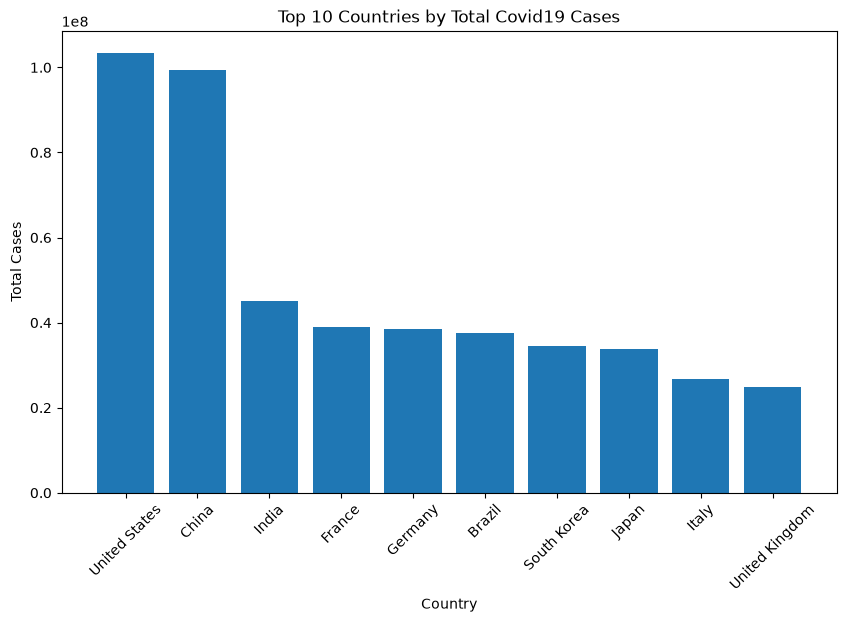

In [47]:
plt.figure(figsize =(10,6))
plt.bar(top_cases['location'], top_cases['total_cases'])
plt.title('Top 10 Countries by Total Covid19 Cases')
plt.xlabel("Country")
plt.ylabel("Total Cases")
plt.xticks(rotation=45)

plt.show()

### Business Insights

• The United States recorded the highest number of confirmed COVID-19 cases in the dataset.

• China and India ranked second and third, indicating that these highly populated countries experienced a significant COVID-19 burden.

• The top 10 countries accounted for a substantial share of global COVID-19 cases, highlighting regions that required extensive public health measures.

In [48]:
daily_cases = covid.groupby('date')['new_cases'].sum().reset_index()

daily_cases.head()

,date,new_cases
0,2020-01-01,0
1,2020-01-02,0
2,2020-01-03,0
3,2020-01-04,0
4,2020-01-05,2


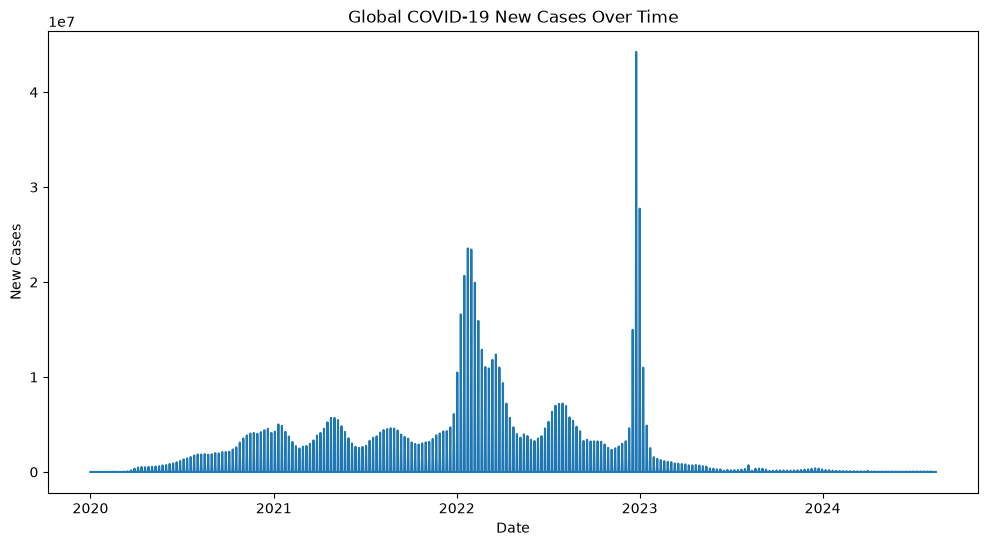

In [49]:
plt.figure(figsize=(12,6))

plt.plot(daily_cases['date'], daily_cases['new_cases'])

plt.title("Global COVID-19 New Cases Over Time")
plt.xlabel("Date")
plt.ylabel("New Cases")



plt.show()

In [50]:
covid.to_csv("covid_cleaned.csv", index=False)

In [53]:
latest_data.to_csv("latest_data.csv", index=False)